# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [13]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [14]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [15]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [16]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [17]:
def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column build a stable token like "site_id=site_id_42", hash it to
    an integer in [0, D), and collect those indices. Use a deterministic hash
    (hashlib), NOT Python's built-in hash() which is salted per process.
    """
    # TODO: hash each "col=value" token into [0, D) and return the index list.
    indices = []
    for col in cols:
        token = f"{col}={row[col]}"
        h = hashlib.md5(token.encode("utf-8")).hexdigest()
        index = int(h, 16) % D
        indices.append(index)
    return indices
    raise NotImplementedError


def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)

## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


_Your derivation here._

Rewrite derivatives: $$ \frac{\partial \ell}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p} $$
The sigmoid derivative: $$ \frac{\partial p}{\partial z} = p(1-p)$$
Use the Chain Rule: $$ \frac{\partial \ell}{\partial z} = \left( -\frac{y}{p} + \frac{1-y}{1-p} \right)p(1-p) $$
Simplify this out and you get: $$\frac{\partial \ell}{\partial z}= p-y$$
Now, the gradient with respect to weights **w**, since we have the following: $$z = \sum_i w_ix_i + b \rightarrow \frac{\partial z}{\partial w_i} = x_i $$
Use the Chain Rule: $$\frac{\partial \ell}{\partial w_i} = \frac{\partial \ell}{\partial z} \cdot \frac{\partial z}{\partial w_i} = (p-y)x_i$$
So, this in vector form is what we need: $$\frac{\partial \ell}{\partial \mathbf{w}} = (p-y)\mathbf{x}$$
Now, the gradient with respect to bias b is relatively straight forward. We have: $$\frac{\partial z}{\partial b} = 1$$
So, it follows that: $$\frac{\partial \ell}{\partial b} = \frac{\partial \ell}{\partial z} = p - y$$
We have derived the two derivatives we need: $$\frac{\partial \ell}{\partial \mathbf{w}} = (p-y)\mathbf{x}, \; \frac{\partial \ell}{\partial b} = p - y$$

What the update looks like for the hashed representation where only a handful of entries of **x** are nonzero is that the update is sparse. Only the weights corresponding to nonzero, the hashed entries of **x**, are updated (bias is also updated at the same rate) while all the other weights remain unchanged.

## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [18]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    w = np.zeros(D)
    b = 0.0
    # TODO: loop over epochs and shuffled examples; apply the SGD update.
    rng = np.random.default_rng(seed)

    for _ in range(epochs):
        index = np.arange(len(y))
        rng.shuffle(index)

        for i in index:
            x = X_idx[i]
            y_i = y[i]

            z = b + w[x].sum()
            p = sigmoid(z)

            grad = p - y_i

            w[x] -= lr * (grad + l2 * w[x])
            b -= lr * grad
    return w, b
    raise NotImplementedError


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))

## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [19]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    # TODO
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    raise NotImplementedError


def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    # TODO
    order = np.argsort(-p)
    y = np.array(y)[order]

    tp = 0
    fp = 0
    fn = np.sum(y == 1)

    precision = []
    recall = []

    for y_i in y:
        if y_i == 1:
            tp += 1
            fn -= 1
        else:
            fp += 1

        precision.append(tp / (tp + fp))
        recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)

    return np.array(recall), np.array(precision)
    raise NotImplementedError

def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    # TODO
    recall, precision = pr_curve(y, p)

    order = np.argsort(recall)
    recall = recall[order]
    precision = precision[order]

    return np.trapezoid(precision, recall)
    raise NotImplementedError

baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4124
model avg precision (PR-AUC): 0.3411
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


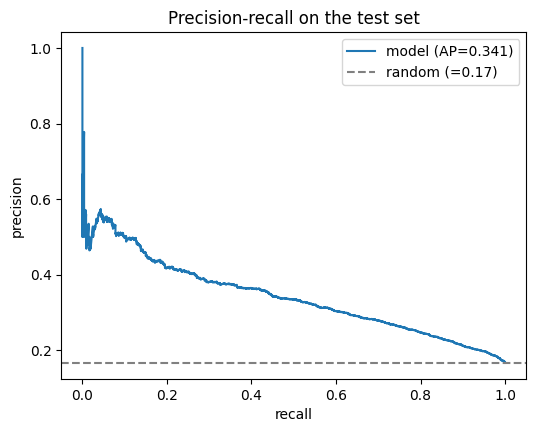

In [20]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [21]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    # TODO for each Dk:
    #   build train/test index matrices at dimension Dk
    #   train logreg, predict on test
    #   record average_precision and log_loss
    Xtr_idx = build_index_matrix(train_df, CAT_COLS, Dk)
    Xte_idx = build_index_matrix(test_df, CAT_COLS, Dk)

    w, b = train_logreg_sgd(Xtr_idx, y_train, Dk)

    p = predict_proba(Xte_idx, w, b)

    ap_by_D.append(average_precision(y_test, p))
    ll_by_D.append(log_loss(y_test, p))
    #raise NotImplementedError

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")

D=2^ 8  AP=0.262  logloss=0.4439
D=2^10  AP=0.299  logloss=0.4330
D=2^12  AP=0.323  logloss=0.4224
D=2^14  AP=0.337  logloss=0.4155
D=2^16  AP=0.340  logloss=0.4134
D=2^18  AP=0.341  logloss=0.4124


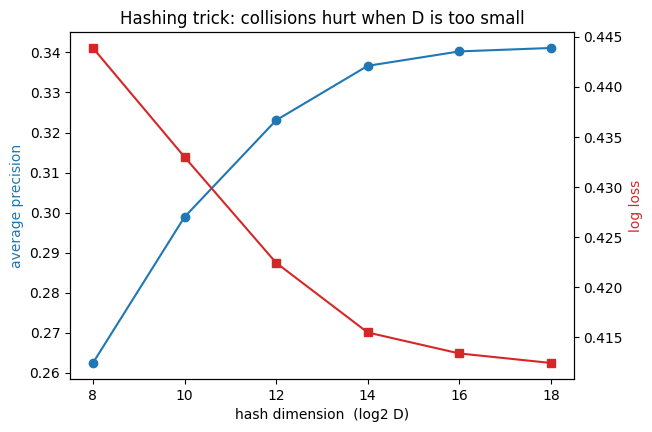

In [22]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [23]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    # TODO
    y = np.array(y)
    p = np.array(p)

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    mean_pred = []
    emp_rate = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (p >= lo) & (p < hi) if i < n_bins - 1 else (p >= lo) & (p <= hi)

        if np.sum(mask) == 0:
            continue

        mean_pred.append(p[mask].mean())
        emp_rate.append(y[mask].mean())

    return np.array(mean_pred), np.array(emp_rate)
    raise NotImplementedError

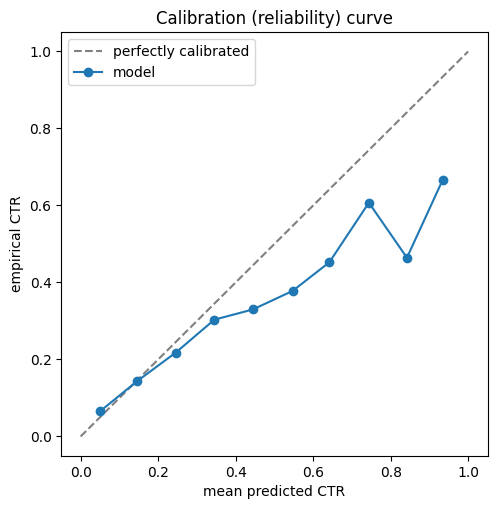

In [24]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


_Your answers here._

1. The accuracy that the trivial "always predict no-click" model gets is 1 - 0.17 so 83%. It is the wrong headline metric here because while it sounds good, it is useless becaue it never finds a single positive, and it ignores ranking entirely. The metrics of log-loss, average precision, and the PR curve are more informative because for log-loss, it evaluates the probability quality; penalizes confident mistakes. The average precision focuses on ranking positives. The PR curve on the other hand shows the tradeoff between precision and recall, which absolutely matters in a rare event detection.
2. What we gain from the hashing trick is a massive memory reduction since we don't have gigantic one-hot vectors anymore. It also does indeed handle unseen categories naturally (hash), and since it is a constant size feature space, it is scalable. What we lose on the other hand is of course the collisions that happen, ie: different features that share the same index. This introduces noise / interference. From my D sweep, the shrinking D starts to hurt at around ~$2^{12} - 2^{14}$, and the reason for this is because as you increase the hash dimension, it reduces collisions and improves performance but with diminishing returns at beyond $2^{16}$. Small D gives you many unrelated features that overwrite each other, while larger D gives you a cleaner signal which in turn leads to better gradients.
3. The two gradients I derived, $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$, the reason why a hashed example updates only a handful of weights is because in the hashed representation, **x** is multi-hot and extremely sparse. It only has k nonzero entries because: $$\frac{\partial \ell}{\partial w_i} = (p-y)x_i$$ If $x_i$ = 0, then the gradient is 0. If $x_i$ = 1, then the gradient is $p - y$. So, only the k hashed indices present in the example get updated, while all other weights remain untouched. The reason that this makes the model scale to billions of features is because even if the feature space is that massive (D), the computing cost per example is not Big O(D), its actually Big O(k). Your memory access equals to only the k weights, you do not need to iterate over the full feature vector.
4. Looking at my calibration curve, while there is pretty good alignment at lower probabilities, at higher predictions, it starts deviating. So, I would say for this particular model, it is *roughly* calibrated, but it of course is not perfect. The reason why ad ranking/bidding need calibrated probabilities and not just a good ranking is because if the probabilities are miscalibrated, you can get a case of overestimation (you overpay for bad ads) or the exact opposite, underestimation (you miss the valuable ads).
5. One way to handle class imbalance is through class weighting. The effect that class weighting would have is it would give more importance to positive examples. The impact that this would have on the PR curve is that it would more than likely shift the curve upward, since better recall at similar precision. For the impact on calibration, it would more than likely worsen it because the model becomes biased towards predicting higher probabilities, and you would need some sort of post calibration to mitigate this.

## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
